Importing necessary libraries

In [1]:
from Datasets.CWRU import DataHelper
from DLModels.SISO.CNNLSTM.Original.Net import Net
from FitLoops.SISO import SimpleTrainer

import numpy as np # type: ignore
import torch # type: ignore
import torch.nn as nn # type: ignore


Setting up experiment parameters

In [2]:
batch_size = 32    # size of mini-batches for training
epochs = 32       # number of complete passes through the training dataset
length = 1024     # sampling length
number = 1000     # number of samples per class
lr = 0.001        # learning rate
test_size = 0.3   # Testing data splited
sensors = ['DE']  # can contain DE=DriveEnd and FE=FanEnd
readRaw = ['RawData/0HP', 'RawData/1HP', 'RawData/2HP','RawData/3HP'] # read conditions data
normalizer = lambda x: (x - np.min(x)) / (np.max(x) - np.min(x)) # Normalize the data between 0 and 1 
save_model = "trained\\"  # path to trained model




Preproccessing the raw CWRU data, and creating Dataset

In [3]:

X = []
Y = []

for path in readRaw:
    raw = DataHelper.read_raw(path , sensors , normalizer)
    argumented_data = DataHelper.argumentation(raw, length=length, number = int(number / len(readRaw)), enc=False)
    Xtemp, Ytemp = DataHelper.add_label(argumented_data)
    if len(X) > 0:
        X = np.concatenate((X, Xtemp))
        Y = np.concatenate((Y, Ytemp))
    else:
        X = Xtemp
        Y = Ytemp

Y = DataHelper.one_hot(Y)

X_train, X_test, y_train, y_test = DataHelper.train_test_spliter(X,Y,test_size)

train_loader = DataHelper.get_torch_dataloder(X_train, y_train, batch_size=batch_size,shuffle=True)
test_loader = DataHelper.get_torch_dataloder(X_test, y_test, batch_size=batch_size,shuffle=True)


In [4]:

# X = X.reshape(10000, 2048, 1) 
X.shape

(10000, 1, 1024)

In [5]:
class CNN(nn.Module):
    '''定义一维卷积神经网络模型'''

    def __init__(self,in_channel=1, out_channel=10):
        super(CNN, self).__init__()
        '''除输入层外，每个层级都包含了卷积、激活和池化三层'''
        '''输出层额外包含了BatchNorm层，提高网络收敛速度以及稳定性'''
        '''第一层卷积核大小为64，之后逐层递减'''
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channel, 16, kernel_size=64, stride=16, padding=24),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=16, padding=8),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.layer3 = nn.Sequential(
            nn.Conv1d(32, 48, kernel_size=8, padding=4),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        self.layer4 = nn.Sequential(
            nn.Conv1d(48, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.layer5 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )
        # 全连接层定义 引入Dropout机制以提高泛化能力
        self.fc = nn.Sequential(
            nn.Linear(64, 128),
            nn.Dropout(0.3),
            nn.ReLU(inplace=True),
            nn.Linear(128, out_channel)
        )
        # 使用softmax函数以计算输出从属于每一类的概率
        self.softmax = nn.Softmax(1)

    def forward(self, x):
        '''前向传播'''
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        # x = x.view(x.size(0), x.size(1), 1)
        # x = self.softmax(x)
        return x

class LSTM_CNN(nn.Module):
    '''定义LSTM-CNN网络模型'''

    def __init__(self, DEVICE, in_channel=3, out_channel=9):
        super(LSTM_CNN, self).__init__()
        self.DEVICE = DEVICE
        '''LSTM相关神经元定义'''
        self.lstm_layer1 = nn.LSTM(in_channel, 32)
        self.lstm_layer2 = nn.LSTM(64, 1)
        self.lstm_fc1 = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 64)
        )

        self.lstm_fc2 = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 64)
        )

        '''CNN相关神经元定义'''
        self.cnn_layer1 = nn.Sequential(
            nn.Conv1d(in_channel, 16, kernel_size=64, stride=16, padding=24),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2))

        self.cnn_layer3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer5 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.Dropout(0.3),
            nn.ReLU(inplace=True),
            nn.Linear(64, out_channel)
        )
        # 使用softmax函数以计算输出从属于每一类的概率
        self.softmax = nn.Softmax(1)

    def forward(self, x):
        '''前向传播'''
        '''*******LSTM*******'''
        # 初始化隐藏神经元
        x_lstm = x.permute(0, 2, 1)
        x_lstm.to(self.DEVICE)
        h1 = torch.zeros(1, 128, 32).to(self.DEVICE)
        c1 = torch.zeros_like(h1).to(self.DEVICE)
        h2 = torch.zeros(1, 128, 1).to(self.DEVICE)
        c2 = torch.zeros_like(h2).to(self.DEVICE)
        y_lstm_ = []
        # 对原时序信号分段
        for i in range(8):
            x_lstm_ = x_lstm[:, i*128:(i+1)*128]
            y, (h1, c1) = self.lstm_layer1(x_lstm_, (h1, c1))
            y = self.lstm_fc1(y)
            y, (h2, c2) = self.lstm_layer2(y, (h2, c2))
            y.to(self.DEVICE)
            y_lstm_.append(y)
        # 合并每一段的结果
        y_lstm = torch.cat(y_lstm_, 1)
        y_lstm = y_lstm.view(y_lstm.size(0), -1)
        y_lstm = self.lstm_fc2(y_lstm)
        '''*******CNN*******'''
        x = self.cnn_layer1(x)
        x = self.cnn_layer2(x)
        x = self.cnn_layer3(x)
        x = self.cnn_layer4(x)
        x = self.cnn_layer5(x)
        x = x.view(x.size(0), -1)
        '''******LSTM+CNN******'''
        # 连接LSTM和CNN的输出，并通过全连接神经元
        x = torch.cat([x, y_lstm], 1)
        x = self.fc(x)
        # x = x.view(x.size(0), x.size(1), 1)
        # y = self.softmax(x)
        return x




class GRU_CNN(nn.Module):
    '''定义LSTM-CNN网络模型'''

    def __init__(self, DEVICE, in_channel=3, out_channel=9):
        super(GRU_CNN, self).__init__()
        self.DEVICE = DEVICE
        '''GRU相关神经元定义'''
        self.gru_layer1 = nn.GRU(in_channel, 32, batch_first=True)
        self.gru_layer2 = nn.GRU(64, 1, batch_first=True)

        # 注意：LSTM的hidden state和cell state合并为GRU的hidden state
        self.gru_fc1 = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 64)
        )

        self.gru_fc2 = nn.Sequential(
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 64)
        )

        '''CNN相关神经元定义保持不变'''
        self.cnn_layer1 = nn.Sequential(
            nn.Conv1d(in_channel, 16, kernel_size=64, stride=16, padding=24),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2))

        self.cnn_layer3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer5 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.Dropout(0.3),
            nn.ReLU(inplace=True),
            nn.Linear(64, out_channel)
        )
        # 使用softmax函数以计算输出从属于每一类的概率
        self.softmax = nn.Softmax(1)

    def forward(self, x):
        '''前向传播'''
        '''*******GRU*******'''
        # 初始化隐藏神经元
        x_gru = x.permute(0, 2, 1)
        x_gru.to(self.DEVICE)
        h1 = torch.zeros(1, x_gru.size(0), 32).to(self.DEVICE)
        h2 = torch.zeros(1, x_gru.size(0), 1).to(self.DEVICE)
        y_gru_ = []
        # 对原时序信号分段
        for i in range(8):
            x_gru_ = x_gru[:, i*128:(i+1)*128]
            # GRU不需要传入hidden state和cell state
            out, h1 = self.gru_layer1(x_gru_, h1)
            out = self.gru_fc1(out)
            out, h2 = self.gru_layer2(out, h2)
            out.to(self.DEVICE)
            y_gru_.append(out)
        # 合并每一段的结果
        y_gru = torch.cat(y_gru_, 1)
        y_gru = y_gru.view(y_gru.size(0), -1)
        y_gru = self.gru_fc2(y_gru)
        '''*******CNN*******'''
        x = self.cnn_layer1(x)
        x = self.cnn_layer2(x)
        x = self.cnn_layer3(x)
        x = self.cnn_layer4(x)
        x = self.cnn_layer5(x)
        x = x.view(x.size(0), -1)
        '''******GRU+CNN******'''
        # 连接GRU和CNN的输出，并通过全连接神经元
        x = torch.cat([x, y_gru], 1)
        x = self.fc(x)
        # x = x.view(x.size(0), x.size(1), 1)
        # y = self.softmax(x)
        return x




class SelfAttentionModel(nn.Module):
    def __init__(self, DEVICE, in_channel=3, out_channel=9, embed_dim=256, num_heads=8):
        super(SelfAttentionModel, self).__init__()
        self.DEVICE = DEVICE
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        # 将输入通道转换为嵌入维度
        self.projection = nn.Linear(1024, embed_dim)

        # 自注意力层
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads)

        '''CNN相关神经元定义保持不变'''
        self.cnn_layer1 = nn.Sequential(
            nn.Conv1d(in_channel, 16, kernel_size=64, stride=16, padding=24),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2))

        self.cnn_layer3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer5 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.fc = nn.Sequential(
            nn.Linear(832, 64),
            nn.Dropout(0.3),
            nn.ReLU(inplace=True),
            nn.Linear(64, out_channel)
        )
        # 使用softmax函数以计算输出从属于每一类的概率
        self.softmax = nn.Softmax(1)

    def forward(self, x):
      #  x_selfattention = x.transpose(0, 1)  # x的形状变为[3, batch_size, 1024]
        x_selfattention = self.projection(x)  # 将输入通道转换为嵌入维度
       # print(x_selfattention.shape)
        # 对每个时间序列维度分别应用自注意力
        x_selfattention, _ = self.attention(x_selfattention, x_selfattention, x_selfattention)  # x的形状仍然是[3, batch_size, embed_dim]

        # 展平时间序列维度，准备分类
        x_selfattention = x_selfattention.view(-1, self.embed_dim * 3)  # x的形状变为[batch_size, embed_dim * 3]

        # x_selfattention = x_selfattention.squeeze(0) 
        '''*******CNN*******'''
        x = self.cnn_layer1(x)
        x = self.cnn_layer2(x)
        x = self.cnn_layer3(x)
        x = self.cnn_layer4(x)
        x = self.cnn_layer5(x)
        x = x.view(x.size(0), -1)
        '''******ATTENTION+CNN******'''
        # 连接GRU和CNN的输出，并通过全连接神经元
        x = torch.cat([x, x_selfattention], 1)
        x = self.fc(x)
        # x = x.view(x.size(0), x.size(1), 1)
        # y = self.softmax(x)
        return x

class SelfAttentionModel2(nn.Module):
    def __init__(self, DEVICE, in_channel=1, out_channel=10, embed_dim=256, num_heads=8):
        super(SelfAttentionModel2, self).__init__()
        self.DEVICE = DEVICE
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        # 将输入通道转换为嵌入维度
        self.projection = nn.Linear(1024, embed_dim)

        # 自注意力层
        self.attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads)

        '''CNN相关神经元定义'''
        self.cnn_layer1 = nn.Sequential(
            nn.Conv1d(in_channel, 16, kernel_size=64, stride=16, padding=24),
            nn.BatchNorm1d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer2 = nn.Sequential(
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2))

        self.cnn_layer3 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer4 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        self.cnn_layer5 = nn.Sequential(
            nn.Conv1d(64, 64, kernel_size=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2, stride=2)
        )

        # 修改全连接层的输入维度
        self.fc = nn.Sequential(
            nn.Linear(320, 64),  # 832 from CNN + embed_dim from attention
            nn.Dropout(0.3),
            nn.ReLU(inplace=True),
            nn.Linear(64, out_channel)
        )

    def forward(self, x):
        # x shape: [batch_size, 1, 1024]
        batch_size = x.size(0)
        
        # Attention branch
        x_selfattention = x.squeeze(1)  # [batch_size, 1024]
        x_selfattention = self.projection(x_selfattention)  # [batch_size, embed_dim]
        x_selfattention = x_selfattention.unsqueeze(0)  # [1, batch_size, embed_dim]
        
        # Apply attention
        x_selfattention, _ = self.attention(x_selfattention, x_selfattention, x_selfattention)
        x_selfattention = x_selfattention.squeeze(0)  # [batch_size, embed_dim]
        
        # CNN branch
        x_cnn = self.cnn_layer1(x)
        x_cnn = self.cnn_layer2(x_cnn)
        x_cnn = self.cnn_layer3(x_cnn)
        x_cnn = self.cnn_layer4(x_cnn)
        x_cnn = self.cnn_layer5(x_cnn)
        x_cnn = x_cnn.view(batch_size, -1)  # Flatten CNN output
        
        # Concatenate features
        x_combined = torch.cat([x_cnn, x_selfattention], dim=1)
        
        # Final classification
        x_out = self.fc(x_combined)
        
        return x_out



loss 0.007, train acc 0.999, test acc 0.869


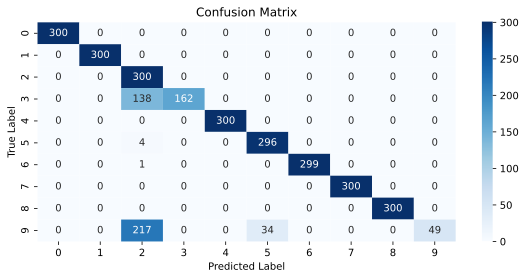

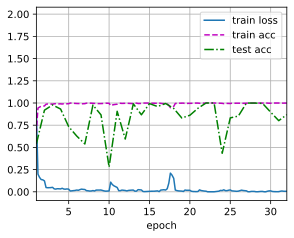

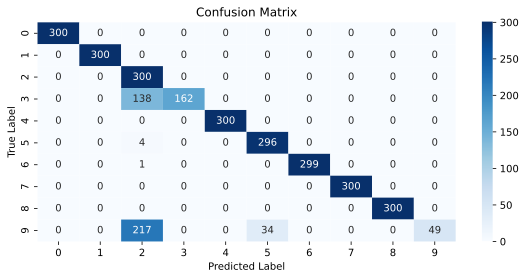

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
net = SelfAttentionModel2(device,1,10,256,4)
loss =  nn.CrossEntropyLoss()  # Suitable for classification problems
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
SimpleTrainer.train(net , train_loader , test_loader , epochs, loss, optimizer, device)
SimpleTrainer.create_confusion_matrix(net, test_loader, 10)

loss 0.003, train acc 0.999, test acc 0.976


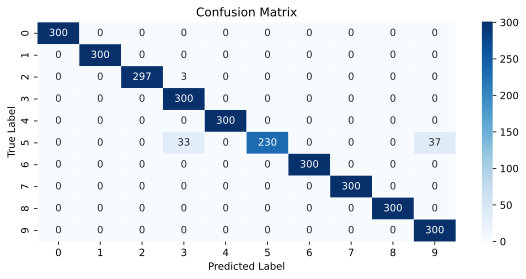

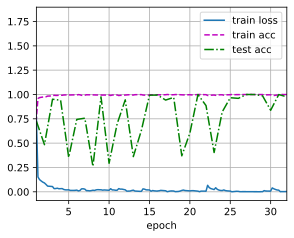

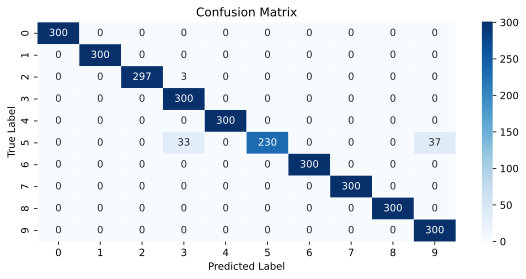

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
net = GRU_CNN(device,1,10)
loss =  nn.CrossEntropyLoss()  # Suitable for classification problems
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
SimpleTrainer.train(net , train_loader , test_loader , epochs, loss, optimizer, device)
SimpleTrainer.create_confusion_matrix(net, test_loader, 10)

loss 0.003, train acc 1.000, test acc 0.999


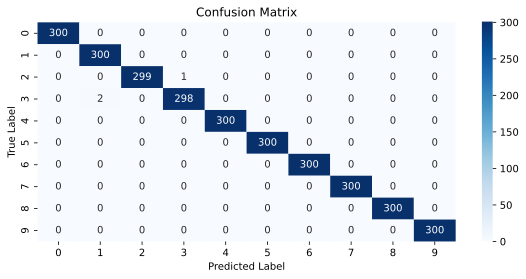

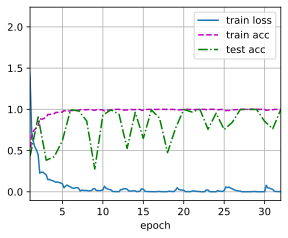

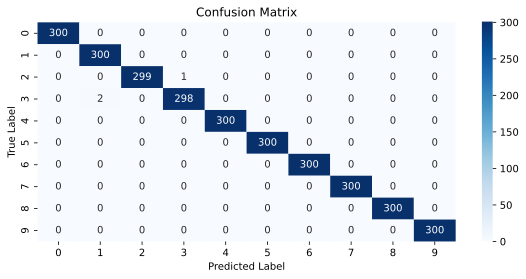

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
net = CNN()
loss =  nn.CrossEntropyLoss()  # Suitable for classification problems
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
SimpleTrainer.train(net , train_loader , test_loader , epochs, loss, optimizer, device)
SimpleTrainer.create_confusion_matrix(net, test_loader, 10)

loss 0.002, train acc 1.000, test acc 1.000


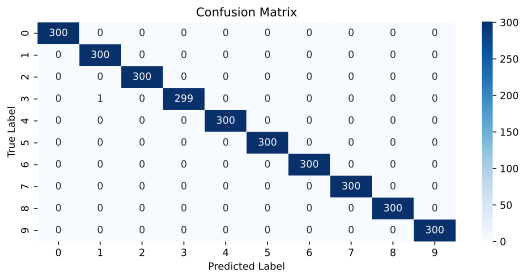

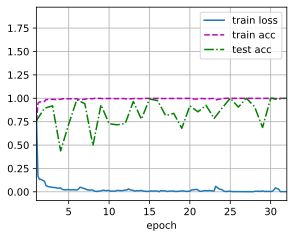

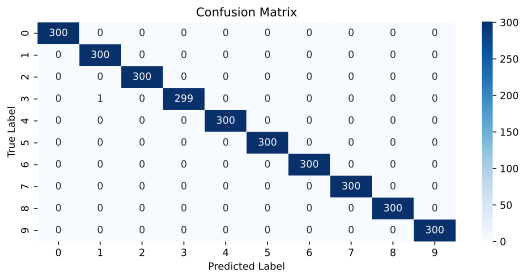

In [10]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
net = LSTM_CNN(device,1,10)
loss =  nn.CrossEntropyLoss()  # Suitable for classification problems
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
SimpleTrainer.train(net , train_loader , test_loader , epochs, loss, optimizer, device)
SimpleTrainer.create_confusion_matrix(net, test_loader, 10)

In [ ]:
# net = Net()
# ps = filter(lambda x: x.requires_grad, net.parameters())
# optimizer =  torch.optim.Adagrad(net.parameters(), lr=lr) #torch.optim.SGD(ps, lr=lr, momentum=0.9, nesterov=True, weight_decay=1e-4)
# loss = nn.BCEWithLogitsLoss()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
# SimpleTrainer.train(net , train_loader , test_loader , epochs, loss, optimizer, device)

In [ ]:
# net = Net()
# ps = filter(lambda x: x.requires_grad, net.parameters())
# optimizer =  torch.optim.Adagrad(net.parameters(), lr=lr) #torch.optim.SGD(ps, lr=lr, momentum=0.9, nesterov=True, weight_decay=1e-4)
# loss = nn.BCEWithLogitsLoss()
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
# SimpleTrainer.train(net , train_loader , test_loader , epochs, loss, optimizer, device)

In [ ]:
SimpleTrainer.create_confusion_matrix(net, test_loader, 10)
